# 3. Matrix Form of Kernels and Induced Geometry

Let $X \in \mathbb{R}^{N \times P}$ be a data matrix whose rows correspond to the samples $x_1, \dots, x_N \in \mathbb{R}^{P}$.

---

**3.1.** Prove that the squared Euclidean distance between two samples $x_i$ and $x_j$ can be written as

$$
\|x_i-x_j\|_2^2 = x_i^\top x_i + x_j^\top x_j - 2x_i^\top x_j.
$$

Starting from this result, derive the full matrix form of the matrix of squared distances between all samples, clearly indicating how the data matrix, the vector of squared norms, and the vector of ones enter the expression.


The data matrix is $X\in\mathbb R^{N\times P}$ and its $i$-th row is $x_i^\top\in\mathbb R^{1\times P}$. Equivalently, the sample itself is regarded as a column vector $x_i\in\mathbb R^P$. With this convention, the Euclidean inner product between two samples is $x_i^\top x_j$, and the $(i,j)$-th entry of $XX^\top$ is precisely

$$
(XX^\top)_{ij}=x_i^\top x_j.
$$

We now prove the pointwise identity for two arbitrary samples $x_i,x_j\in\mathbb R^P$.

By definition of the Euclidean norm,

$$
\|x_i-x_j\|_2^2=(x_i-x_j)^\top(x_i-x_j).
$$

Expanding the bilinear form gives

$$
\begin{aligned}
\|x_i-x_j\|_2^2
&=x_i^\top x_i-x_i^\top x_j-x_j^\top x_i+x_j^\top x_j.
\end{aligned}
$$

Since $x_i^\top x_j$ is a scalar, we have $x_i^\top x_j=x_j^\top x_i$. Therefore,

$$
\boxed{\|x_i-x_j\|_2^2=x_i^\top x_i+x_j^\top x_j-2x_i^\top x_j.}
$$

This is the desired identity.

## Matrix form for all pairwise squared distances

Define the squared-distance matrix $D\in\mathbb R^{N\times N}$ by

$$
D_{ij}=\|x_i-x_j\|_2^2, \qquad 1\le i,j\le N.
$$

Also define the Gram matrix of the original data,

$$
G=XX^\top\in\mathbb R^{N\times N},
$$

whose entries are

$$
G_{ij}=x_i^\top x_j.
$$

Next define the vector of squared row norms,

$$
s=
\begin{bmatrix}
\|x_1\|_2^2\\
\vdots\\
\|x_N\|_2^2
\end{bmatrix}
\in\mathbb R^N.
$$

Equivalently,

$$
s=\operatorname{diag}(XX^\top),
$$

where $\operatorname{diag}(A)$ denotes the vector formed by the diagonal entries of a square matrix $A$. If $\mathbf 1_N\in\mathbb R^N$ denotes the all-ones vector, then

$$
s\mathbf 1_N^\top\in\mathbb R^{N\times N}
\quad\text{and}\quad
\mathbf 1_N s^\top\in\mathbb R^{N\times N}
$$

are the matrices whose entries are respectively

$$
(s\mathbf 1_N^\top)_{ij}=s_i=\|x_i\|_2^2,
\qquad
(\mathbf 1_N s^\top)_{ij}=s_j=\|x_j\|_2^2.
$$

Moreover, because $G=XX^\top$, its $(i,j)$-th entry is

$$
G_{ij}=(XX^\top)_{ij}=x_i^\top x_j.
$$

Using the scalar identity proved above, for every pair $(i,j)$ we obtain

$$
D_{ij}=\|x_i\|_2^2+\|x_j\|_2^2-2x_i^\top x_j
=s_i+s_j-2G_{ij}.
$$

On the other hand, the $(i,j)$-th entry of the matrix

$$
s\mathbf 1_N^\top+\mathbf 1_N s^\top-2XX^\top
$$

is exactly

$$
(s\mathbf 1_N^\top)_{ij}+(\mathbf 1_N s^\top)_{ij}-2(XX^\top)_{ij}
=s_i+s_j-2x_i^\top x_j
=D_{ij}.
$$

Therefore the two matrices coincide entrywise for every $i,j$, and hence

$$
\boxed{D=s\mathbf 1_N^\top+\mathbf 1_N s^\top-2XX^\top.}
$$

This is the complete matrix form of the pairwise squared-distance matrix.

## Dimensional check

The dimensions are consistent:

- $X\in\mathbb R^{N\times P}$;
- $XX^\top\in\mathbb R^{N\times N}$;
- $s\in\mathbb R^N$;
- $\mathbf 1_N\in\mathbb R^N$;
- $s\mathbf 1_N^\top,\ \mathbf 1_N s^\top\in\mathbb R^{N\times N}$.

Hence all three terms in the formula for $D$ belong to $\mathbb R^{N\times N}$.

## Interpretation

The formula

$$
D=s\mathbf 1_N^\top+\mathbf 1_N s^\top-2XX^\top
$$

shows that the full geometry of pairwise squared Euclidean distances is encoded by two types of information:

- the row-constant matrix $s\mathbf 1_N^\top$, which replicates the squared norm $s_i=\|x_i\|_2^2$ across the $i$-th row;
- the column-constant matrix $\mathbf 1_N s^\top$, which replicates the squared norm $s_j=\|x_j\|_2^2$ across the $j$-th column;
- the interaction term $-2XX^\top$, containing all pairwise inner products.

Thus the matrix expression separates the contribution of the individual sample norms from the contribution of the pairwise inner products, and together these terms determine every entry $D_{ij}=\|x_i-x_j\|_2^2$. In this sense, it provides a compact algebraic representation of the complete pairwise squared-distance structure of the dataset.

---


**3.2.** Consider a Gaussian or RBF kernel matrix built from the squared distances between the samples. Explain why its diagonal entries take a constant value and interpret this result geometrically. In addition, discuss the symmetry and positive-semidefiniteness properties of the kernel matrix, indicating why these properties allow it to be interpreted as a Gram matrix associated with a feature space.


Let

$$
k_\gamma(x_i,x_j)=\exp\bigl(-\gamma\|x_i-x_j\|_2^2\bigr),
\qquad \gamma>0,
$$

be the Gaussian RBF kernel on $\mathbb R^P$. The associated kernel matrix $K\in\mathbb R^{N\times N}$ is defined by

$$
K_{ij}=k_\gamma(x_i,x_j)=\exp\bigl(-\gamma\|x_i-x_j\|_2^2\bigr).
$$

Using the squared-distance matrix derived in item 3.1,

$$
D_{ij}=\|x_i-x_j\|_2^2,
$$

we may equivalently write the kernel matrix in entrywise form as

$$
K=\exp(-\gamma D),
$$

where the exponential is understood entrywise (that is, componentwise, not as the matrix exponential).

## Diagonal entries

For every $i\in\{1,\dots,N\}$,

$$
K_{ii}=\exp\bigl(-\gamma\|x_i-x_i\|_2^2\bigr)=\exp(0)=1.
$$

Hence all diagonal entries are equal, and in fact

$$
\boxed{K_{ii}=1 \quad \text{for all } i.}
$$

Thus the diagonal is constant because every sample has zero distance from itself.

## Geometric interpretation of the diagonal

A symmetric positive-definite kernel in the kernel-theoretic sense admits a feature map $\phi:\mathbb R^P\to\mathcal H$ into a Hilbert space $\mathcal H$ such that

$$
k_\gamma(x,z)=\langle \phi(x),\phi(z)\rangle_{\mathcal H}.
$$

Therefore,

$$
K_{ii}=k_\gamma(x_i,x_i)=\langle \phi(x_i),\phi(x_i)\rangle_{\mathcal H}=\|\phi(x_i)\|_{\mathcal H}^2.
$$

Since $K_{ii}=1$, it follows that

$$
\|\phi(x_i)\|_{\mathcal H}=1,
\qquad i=1,\dots,N.
$$

Geometrically, all embedded samples lie on the unit sphere of the feature space. The kernel value $K_{ij}$ is then the inner product between two unit vectors $\phi(x_i)$ and $\phi(x_j)$, so it measures their similarity in the feature geometry induced by the Gaussian kernel. Moreover,

$$
\begin{aligned}
\|\phi(x_i)-\phi(x_j)\|_{\mathcal H}^2
&=\|\phi(x_i)\|_{\mathcal H}^2+\|\phi(x_j)\|_{\mathcal H}^2-2\langle \phi(x_i),\phi(x_j)\rangle_{\mathcal H}\\
&=1+1-2K_{ij}=2-2K_{ij}.
\end{aligned}
$$

Thus the Gaussian kernel does not merely place all embedded points on the unit sphere: it also determines their pairwise distances in feature space directly through the kernel values. Nearby points in the original space have small squared distance, hence $K_{ij}$ is close to $1$ and the corresponding feature-space distance is small; far-apart points in the original space have larger squared distance, hence $K_{ij}$ is closer to $0$ and the corresponding feature-space distance is larger.

## Symmetry

Because the squared Euclidean distance is symmetric,

$$
\|x_i-x_j\|_2^2=\|x_j-x_i\|_2^2,
$$

we obtain

$$
K_{ij}=\exp\bigl(-\gamma\|x_i-x_j\|_2^2\bigr)
=\exp\bigl(-\gamma\|x_j-x_i\|_2^2\bigr)=K_{ji}.
$$

Therefore,

$$
\boxed{K=K^\top.}
$$

So the Gaussian kernel matrix is symmetric.

## Positive semidefiniteness

We now show why $K$ is positive semidefinite as a matrix. Let $c=(c_1,\dots,c_N)^\top\in\mathbb R^N$ be arbitrary. Then

$$
c^\top Kc=\sum_{i=1}^N\sum_{j=1}^N c_i c_j\, k_\gamma(x_i,x_j).
$$

The Gaussian kernel is a symmetric positive-definite kernel on $\mathbb R^P$ in the kernel-theoretic sense. One rigorous justification is given by Bochner's theorem: the function

$$
\psi(h)=\exp(-\gamma\|h\|_2^2), \qquad h\in\mathbb R^P,
$$

is translation invariant, and its Fourier transform is a nonnegative function,

$$
\widehat \psi(\omega)=\left(\frac{\pi}{\gamma}\right)^{P/2}
\exp\left(-\frac{\|\omega\|_2^2}{4\gamma}\right)\ge 0,
\qquad \omega\in\mathbb R^P.
$$

Hence $k_\gamma(x,z)=\psi(x-z)$ is positive definite as a kernel. Consequently, for every finite sample the associated kernel matrix satisfies

$$
c^\top Kc\ge 0
\qquad \text{for every } c\in\mathbb R^N.
$$

Therefore,

$$
\boxed{K\succeq 0.}
$$

That is, the Gaussian kernel matrix is symmetric positive semidefinite. In general it is not necessary to claim positive definiteness of the matrix for every finite sample, since repeated points or linear dependencies in feature space may produce nontrivial vectors $c$ such that $c^\top Kc=0$.

## Why this makes $K$ a Gram matrix

Since $k_\gamma$ is a symmetric positive-definite kernel, the Moore-Aronszajn theorem guarantees the existence of a Hilbert space $\mathcal H_{k_\gamma}$ and a feature map

$$
\phi:\mathbb R^P\to \mathcal H_{k_\gamma}
$$

such that

$$
k_\gamma(x_i,x_j)=\langle \phi(x_i),\phi(x_j)\rangle_{\mathcal H_{k_\gamma}}.
$$

Therefore the entries of $K$ satisfy

$$
K_{ij}=\langle \phi(x_i),\phi(x_j)\rangle_{\mathcal H_{k_\gamma}},
$$

which is exactly the definition of a Gram matrix. Equivalently, for every $c\in\mathbb R^N$,

$$
\begin{aligned}
c^\top Kc
&=\sum_{i=1}^N\sum_{j=1}^N c_i c_j\,k_\gamma(x_i,x_j)\\
&=\sum_{i=1}^N\sum_{j=1}^N c_i c_j\,\langle \phi(x_i),\phi(x_j)\rangle_{\mathcal H_{k_\gamma}}\\
&=\left\langle \sum_{i=1}^N c_i\phi(x_i),\sum_{j=1}^N c_j\phi(x_j)\right\rangle_{\mathcal H_{k_\gamma}}\\
&=\left\|\sum_{i=1}^N c_i\phi(x_i)\right\|_{\mathcal H_{k_\gamma}}^2\ge 0.
\end{aligned}
$$

This identity makes transparent why symmetry and positive semidefiniteness are precisely the structural properties expected of a matrix of inner products. Thus $K$ is the Gram matrix of the embedded points $\phi(x_1),\dots,\phi(x_N)$ in the feature space associated with the Gaussian kernel.

Equivalently, if one argues purely in finite-dimensional linear algebra, every symmetric positive semidefinite matrix admits a factorization

$$
K=BB^\top
$$

for some matrix $B$. Then $K_{ij}=\langle b_i,b_j\rangle$, where $b_i^\top$ is the $i$-th row of $B$. This is precisely the finite-dimensional Gram representation. The RKHS point of view identifies the canonical feature space in which this representation is induced by the kernel itself.

## Conclusion

The Gaussian kernel matrix built from pairwise squared distances satisfies the following properties:

- its diagonal entries are constant and equal to $1$, because each point has zero distance from itself;
- it is symmetric, because squared Euclidean distance is symmetric;
- it is positive semidefinite, because the Gaussian function is a positive-definite kernel.

These properties imply that $K$ can be interpreted as a Gram matrix of inner products between feature vectors in a Hilbert space. Conceptually, the roles of the two spaces must be kept distinct: the squared Euclidean distances $\|x_i-x_j\|_2^2$ are computed in the original input space $\mathbb R^P$, whereas the Gram interpretation $K_{ij}=\langle \phi(x_i),\phi(x_j)\rangle$ takes place in the induced Hilbert feature space $\mathcal H_{k_\gamma}$. Geometrically, the Gaussian kernel embeds all samples onto the unit sphere of that feature space, and both their inner products and their feature-space distances are determined by the kernel values.


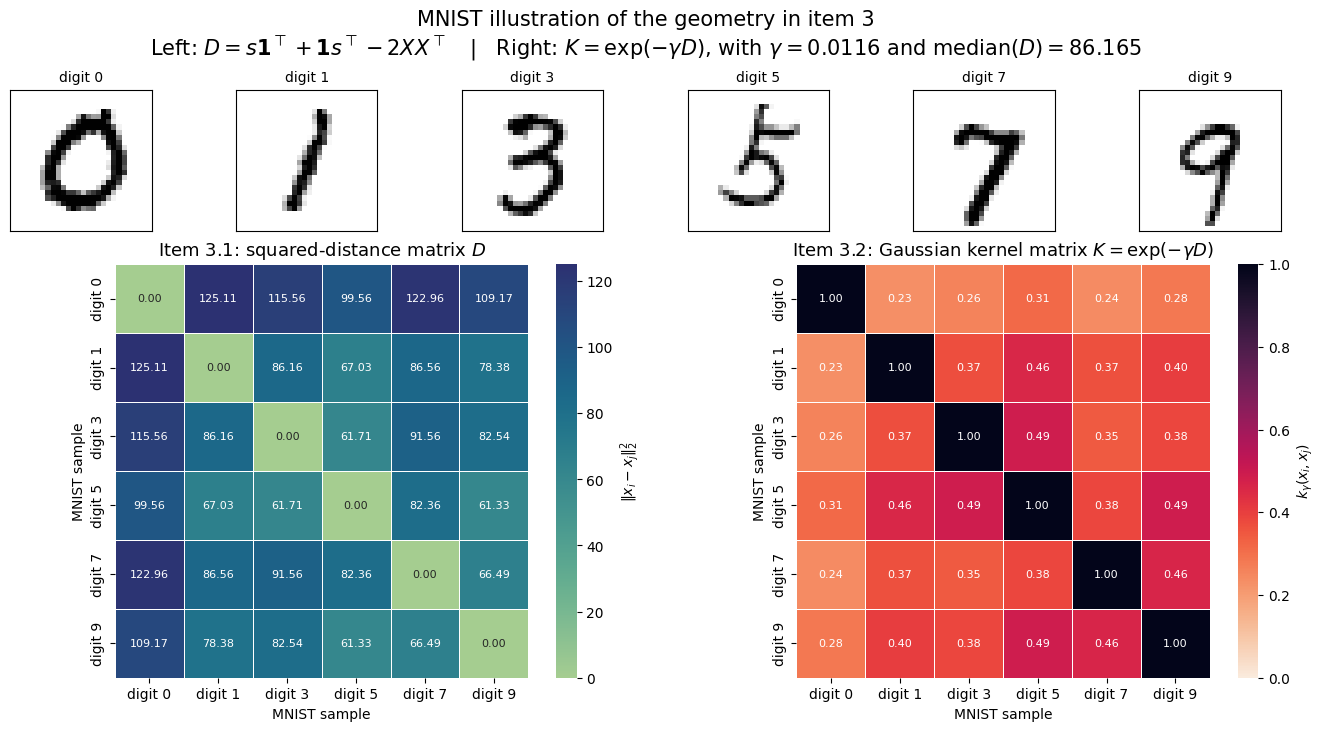

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml


def find_repo_root(start: Path | None = None) -> Path:
    """Locate the repository root so notebook execution is robust to the current working directory."""
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


def load_mnist_openml() -> tuple[np.ndarray, np.ndarray]:
    """Load MNIST and cache the downloaded files under data/raw."""
    repo_root = find_repo_root()
    data_home = repo_root / "data" / "raw"
    data_home.mkdir(parents=True, exist_ok=True)

    mnist = fetch_openml(
        "mnist_784",
        version=1,
        as_frame=False,
        data_home=data_home,
        parser="auto",
    )
    X_all = mnist.data.astype(np.float64) / 255.0
    y_all = mnist.target.astype(np.int64)
    return X_all, y_all


def select_representative_digits(
    X_all: np.ndarray,
    y_all: np.ndarray,
    digits: list[int],
    pool_per_digit: int = 400,
) -> tuple[np.ndarray, list[str]]:
    """Pick one representative MNIST image per digit using proximity to the class mean."""
    rows = []
    labels = []
    for digit in digits:
        idx = np.flatnonzero(y_all == digit)
        pool = idx[:pool_per_digit]
        X_digit = X_all[pool]
        class_mean = np.mean(X_digit, axis=0, keepdims=True)
        rep_local_idx = int(np.argmin(np.sum((X_digit - class_mean) ** 2, axis=1)))
        rows.append(X_digit[rep_local_idx])
        labels.append(str(digit))
    return np.vstack(rows), labels


def median_heuristic_gamma(X: np.ndarray) -> tuple[float, float]:
    """Choose gamma from the inverse median positive pairwise squared distance."""
    sq_dists = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=2)
    upper = sq_dists[np.triu_indices(X.shape[0], k=1)]
    positive_upper = upper[upper > 0.0]
    if positive_upper.size == 0:
        raise ValueError("The median heuristic is undefined when all sampled distances are zero.")

    median_sq = float(np.median(positive_upper))
    return 1.0 / median_sq, median_sq


X_all, y_all = load_mnist_openml()

example_digits = [0, 1, 3, 5, 7, 9]
X_example, labels = select_representative_digits(X_all, y_all, example_digits)

G_linear = X_example @ X_example.T
s = np.diag(G_linear)
D = s[:, None] + s[None, :] - 2.0 * G_linear
D_direct = np.sum((X_example[:, None, :] - X_example[None, :, :]) ** 2, axis=2)
np.testing.assert_allclose(D, D_direct, atol=1e-10)

gamma_rbf, median_sq_distance = median_heuristic_gamma(X_example)
K_rbf = np.exp(-gamma_rbf * D)
np.testing.assert_allclose(np.diag(K_rbf), np.ones(K_rbf.shape[0]), atol=1e-12)

sample_labels = [f"digit {label}" for label in labels]
distance_df = pd.DataFrame(D, index=sample_labels, columns=sample_labels)
kernel_df = pd.DataFrame(K_rbf, index=sample_labels, columns=sample_labels)

fig = plt.figure(figsize=(13.5, 7.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[0.9, 2.2])
image_grid = grid[0, :].subgridspec(1, len(labels), wspace=0.06)

for idx, label in enumerate(labels):
    ax = fig.add_subplot(image_grid[0, idx])
    ax.imshow(X_example[idx].reshape(28, 28), cmap="gray_r", vmin=0.0, vmax=1.0)
    ax.set_title(f"digit {label}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

ax_dist = fig.add_subplot(grid[1, 0])
sns.heatmap(
    distance_df,
    ax=ax_dist,
    cmap="crest",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": r"$\|x_i - x_j\|_2^2$"},
    annot_kws={"fontsize": 8},
)
ax_dist.set_title(r"Item 3.1: squared-distance matrix $D$", fontsize=13)
ax_dist.set_xlabel("MNIST sample")
ax_dist.set_ylabel("MNIST sample")

ax_kernel = fig.add_subplot(grid[1, 1])
sns.heatmap(
    kernel_df,
    ax=ax_kernel,
    cmap="rocket_r",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": r"$k_\gamma(x_i,x_j)$"},
    annot_kws={"fontsize": 8},
)
ax_kernel.set_title(r"Item 3.2: Gaussian kernel matrix $K = \exp(-\gamma D)$", fontsize=13)
ax_kernel.set_xlabel("MNIST sample")
ax_kernel.set_ylabel("MNIST sample")

fig.suptitle(
    "MNIST illustration of the geometry in item 3\n"
    + r"Left: $D = s\mathbf{1}^\top + \mathbf{1}s^\top - 2XX^\top$"
    + "   |   "
    + rf"Right: $K = \exp(-\gamma D)$, with $\gamma = {gamma_rbf:.4f}$ and median$(D) = {median_sq_distance:.3f}$",
    fontsize=15,
)
plt.show()
